In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from sklearn.cluster import KMeans
from sklearn import preprocessing
import matplotlib.pyplot as pl
import seaborn as sns

#source: https://stackoverflow.com/questions/33458834/k-means-clustering-in-python
#source: https://stackoverflow.com/questions/57986346/how-to-do-clustering-with-k-means-algorithm-for-an-imported-data-set-with-proper
#genAI used in debugging and where directly cited

In [7]:
project_location = Path.cwd()
data_location = Path.cwd().parent/"data"/"additional"
print(project_location)

/Users/oliviawesel/Desktop/soccer-analytics-capstone-template/analysis


In [8]:
# path = project_location/ 'all_k_means.csv'
df = pd.read_parquet(data_location/'all_k_means.parquet')
print(df.head())

   player_id  pct_shot_first_time  pct_shot_follows_dribble  \
0      26101             0.200000                       0.0   
1      40486             0.428571                       0.0   
2      19757             0.252427                       0.0   
3       3629             0.273504                       0.0   
4       3616             0.210526                       0.0   

   pct_shot_open_goal  pct_shot_dominant_foot  pct_shot_header  \
0            0.000000                0.800000         0.000000   
1            0.035714                0.607143         0.178571   
2            0.009709                0.864078         0.019417   
3            0.025641                0.529915         0.059829   
4            0.000000                0.736842         0.052632   

   pct_shot_goal_scored  pct_shot_taken_saved  shots_per_minute  \
0              0.000000              0.000000          0.054536   
1              0.035714              0.000000          0.024415   
2              0.067961

In [9]:
df.isnull().sum()
print(len(df))

9035


In [10]:
df.dropna(inplace=True)
print(len(df))

4840


In [11]:
df = df.drop(columns=['player_id'])

In [12]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute
0,0.200000,0.0,0.000000,0.800000,0.000000,0.000000,0.000000,0.250521,0.051628,0.200000,...,0.219893,1.000000,0.000000,0.125000,0.125000,0.107143,0.200000,0.085714,0.822704,0.000000
1,0.428571,0.0,0.035714,0.607143,0.178571,0.035714,0.000000,0.092849,0.039793,0.142857,...,0.136577,0.223881,0.500000,0.029474,0.246842,0.415263,0.400842,0.355368,0.306767,0.107984
2,0.252427,0.0,0.009709,0.864078,0.019417,0.067961,0.009709,0.089033,0.060456,0.058252,...,0.281873,0.285714,0.512821,0.069519,0.074866,0.349885,0.485324,0.385842,0.284568,0.220854
3,0.273504,0.0,0.025641,0.529915,0.059829,0.136752,0.000000,0.159993,0.049096,0.213675,...,0.122901,0.352941,0.583333,0.060519,0.214337,0.426873,0.441114,0.321614,0.297962,0.119835
4,0.210526,0.0,0.000000,0.736842,0.052632,0.315789,0.000000,0.093133,0.065081,0.315789,...,0.050856,0.500000,0.000000,0.000000,0.089172,0.391720,0.404246,0.275159,0.375341,0.108581


In [13]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

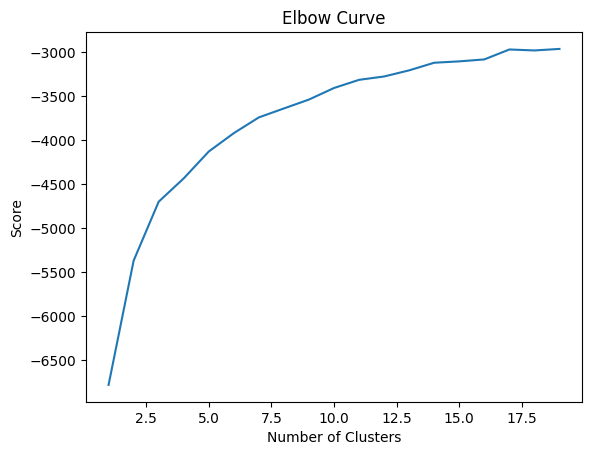

In [14]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [15]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute,cluster
0,0.200000,0.0,0.000000,0.800000,0.000000,0.000000,0.000000,0.054536,-0.299891,0.200000,...,1.000000,0.000000,0.017857,0.035714,0.071429,0.107143,0.053571,0.767857,0.000000,4
1,0.428571,0.0,0.035714,0.607143,0.178571,0.035714,0.000000,0.024415,-2.262913,0.142857,...,0.223881,0.500000,0.004211,0.070526,0.276842,0.214737,0.222105,0.286316,0.011303,0
2,0.252427,0.0,0.009709,0.864078,0.019417,0.067961,0.009709,0.023686,1.164438,0.058252,...,0.285714,0.512821,0.009931,0.021390,0.233257,0.259995,0.241151,0.265597,0.023117,3
3,0.273504,0.0,0.025641,0.529915,0.059829,0.136752,0.000000,0.037241,-0.719881,0.213675,...,0.352941,0.583333,0.008646,0.061239,0.284582,0.236311,0.201009,0.278098,0.012543,0
4,0.210526,0.0,0.000000,0.736842,0.052632,0.315789,0.000000,0.024469,1.931559,0.315789,...,0.500000,0.000000,0.000000,0.025478,0.261146,0.216561,0.171975,0.350318,0.011365,0


In [16]:
len(df.columns)

45

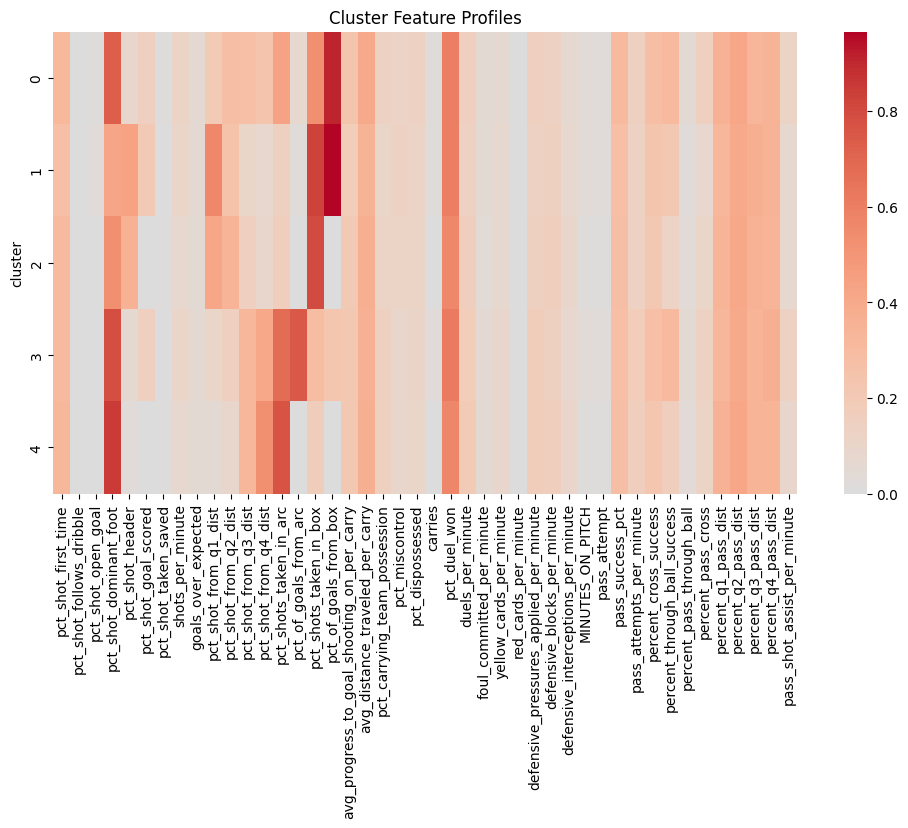

In [17]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

## Carry K-Means

In [20]:
df = pd.read_parquet(data_location/'carry_k_means.parquet')
print(df.head())

   player_id  avg_progress_to_goal_shooting_on_per_carry  \
0      11746                                    1.014954   
1       3477                                    2.682264   
2       3874                                    1.544288   
3       3629                                    3.896256   
4      10499                                    3.279143   

   avg_distance_traveled_per_carry  pct_carrying_team_possession  \
0                         4.399259                      0.042749   
1                         7.050323                      0.026689   
2                         5.080311                      0.044520   
3                         8.452967                      0.061305   
4                         7.355203                      0.038172   

   pct_miscontrol  pct_dispossessed  carries  
0        0.021505          0.053763     93.0  
1        0.106855          0.087702    992.0  
2        0.018397          0.029566   1522.0  
3        0.074249          0.058928   1697

In [21]:
df.isnull().sum()
print(len(df))

8986


In [22]:
df.dropna(inplace=True)
print(len(df))

5698


In [23]:
df = df.drop(columns=['player_id'])

In [24]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,avg_progress_to_goal_shooting_on_per_carry,avg_distance_traveled_per_carry,pct_carrying_team_possession,pct_miscontrol,pct_dispossessed,carries
0,0.092036,0.237918,0.126973,0.043011,0.143369,0.002285
1,0.243227,0.462079,0.075298,0.213710,0.233871,0.025633
2,0.140035,0.295504,0.132675,0.036794,0.078844,0.039397
3,0.353311,0.580680,0.186683,0.148497,0.157140,0.043942
4,0.297352,0.487859,0.112247,0.114695,0.114695,0.007116


In [25]:
c = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

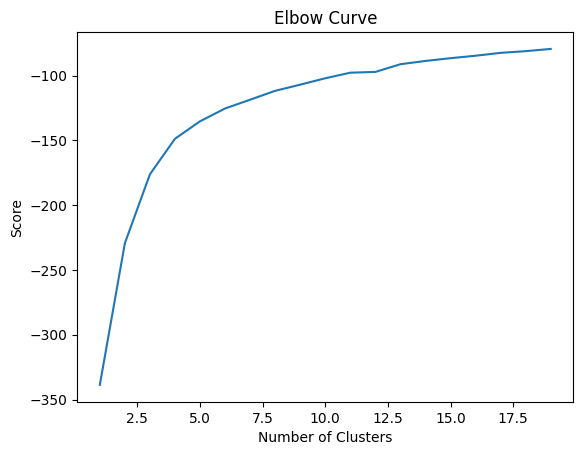

In [26]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [27]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df.head()

,avg_progress_to_goal_shooting_on_per_carry,avg_distance_traveled_per_carry,pct_carrying_team_possession,pct_miscontrol,pct_dispossessed,carries,cluster
0,1.014954,4.399259,0.042749,0.021505,0.053763,93.0,4
1,2.682264,7.050323,0.026689,0.106855,0.087702,992.0,3
2,1.544288,5.080311,0.044520,0.018397,0.029566,1522.0,4
3,3.896256,8.452967,0.061305,0.074249,0.058928,1697.0,3
4,3.279143,7.355203,0.038172,0.057348,0.043011,279.0,3


In [28]:
len(df.columns)

7

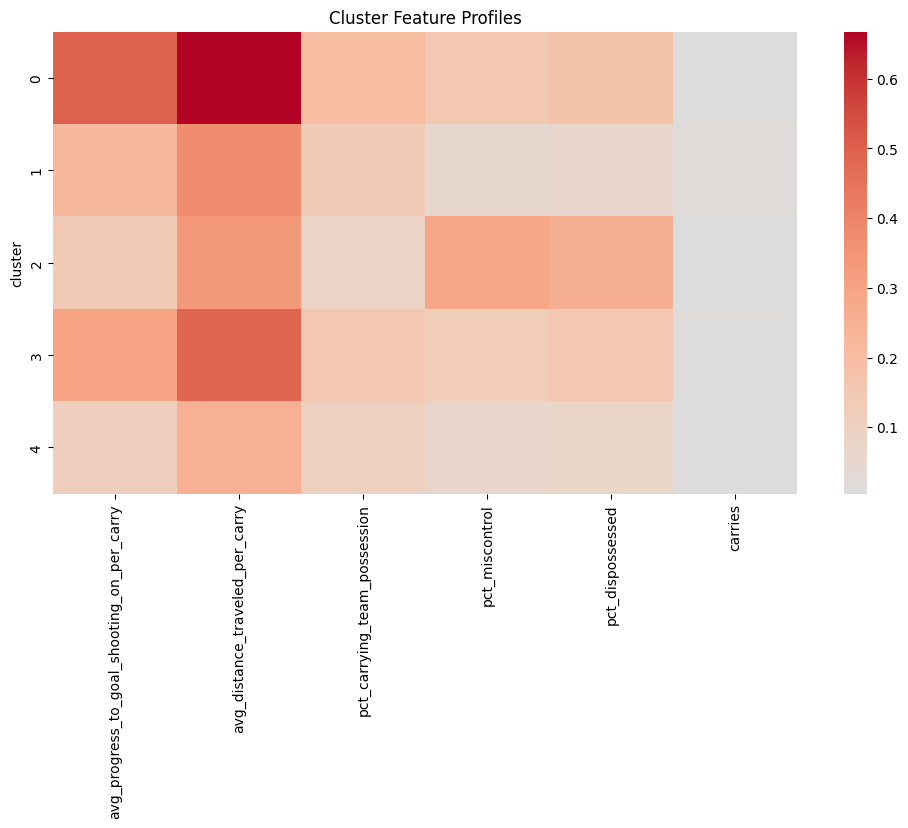

In [29]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()